<a href="https://colab.research.google.com/github/LeidyRuiz-Diaz/analisis-neuronal-insectos/blob/main/Practica_S4_RuizLeidy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica Sesión 4 — Del ruido a las dos bandas

**De la neurona a la figura · Análisis neuronal en insectos asistido por IA**

En la Sesión 3 detectaste espigas en una señal **limpia**. Los datos reales no se ven así:
traen ruido de la red eléctrica, deriva lenta y ruido térmico que puede tapar por completo
a las neuronas lejanas.

Hoy tomas una señal cruda realista y la separas en sus partes:

1. Mirarla y describirla.
2. Diagnosticar **qué** ruido tiene, con el espectro de potencia.
3. Quitar el ruido de red (filtro *notch* a 60 Hz).
4. Separar la **banda LFP** (lo lento) y la **banda AP** (lo rápido).
5. Detectar espigas sobre la banda AP con un umbral basado en el ruido.
6. Comprobar que **LFP + AP = la señal original** — el filtrado separa, no inventa.

Medir **cuántas acertaste** (verdaderos positivos, falsos positivos y falsos negativos) es
el tema del **Taller 1**, que es calificable. Hoy el objetivo es el pipeline.

Igual que en la Sesión 3, **el código lo escribes tú**. Lo que te damos es la señal,
la especificación de cada función y una forma de comprobar si lo que hiciste funciona.


## Cómo funciona este taller

Los mismos tres tipos de ejercicio de la Sesión 3. El icono te dice qué te toca hacer:

| | Ejercicio | Qué haces |
|---|---|---|
| ✏️ | **Completa el código** | La celda tiene huecos marcados con `____`. El código **no corre** hasta que los llenes todos. |
| 📋 | **Pega este prompt** | Copia el prompt tal cual en ChatGPT o Claude, lee la respuesta y decide si sirve antes de usarla. |
| ✍️ | **Escribe tu prompt** | Lo redactas tú, con los 5 elementos de abajo. Escríbelo en la celda de texto: **hace parte de la entrega**. |

Después de los ejercicios numéricos hay una celda de **✅ verificación**: te dice si tu
resultado es correcto, pero no cómo llegar a él.

### Los 5 elementos de un prompt de programación

1. **Lenguaje.** Python. (Basta decirlo una vez, al inicio del chat.)
2. **Tipo de tarea.** Graficar, filtrar, detectar, comparar, calcular.
3. **Subtipo de tarea.** Espectro con Welch, filtro Butterworth de fase cero, notch a 60 Hz, umbral robusto.
4. **Tipo de datos.** *"Un array de numpy `cruda` con 40 000 muestras de voltaje en µV, muestreado a 20 000 Hz, donde las espigas son picos negativos."*
5. **Exigencias de calidad.** Ejes rotulados con unidades, que explique qué hace cada línea, que no use librerías extra.

⚠️ Regla del curso: **nunca pegues código que no puedas explicar en voz alta.**

### Lo que ya traes de la Sesión 3

Tu notebook de la Sesión 3 tiene dos funciones que hoy vas a **reutilizar**: `ver()` y
`detectar()`. Ábrelo en otra pestaña y ténlo a mano — copiar tu propio código y adaptarlo
es exactamente lo que hace un laboratorio real.

## 0 · Preparación

Ejecuta esta celda primero. Te la damos hecha: define el estilo del curso, la frecuencia
de muestreo, la función `revisar()` que usarás para comprobar tus resultados y la función
`pot()`, que mide cuánta potencia tiene una señal en un rango de frecuencias.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sg      # scipy.signal: filtros y análisis espectral

# Estilo del curso
NAVY, TEAL, ORANGE, GRAY = "#0E2841", "#156082", "#E97132", "#6E6E6E"
plt.rcParams.update({"figure.figsize": (11, 3.2), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

FS  = 20000                     # frecuencia de muestreo (Hz) -> 20 kHz, como en el laboratorio
DUR = 2.0                       # duración del registro (segundos)
t   = np.arange(0, DUR, 1/FS)   # vector de tiempos, una entrada por muestra

def revisar(nombre, condicion, pista=""):
    """Imprime si una comprobación pasó. No te dice cómo arreglarla, solo qué falla."""
    if condicion:
        print("  OK   ", nombre)
    else:
        print("  FALLA", nombre, ("  ->  pista: " + pista) if pista else "")

def pot(x, f0, f1):
    """Potencia de la señal x entre f0 y f1 Hz (suma del espectro en ese rango)."""
    f, P = sg.welch(x, FS, nperseg=8192)
    return float(P[(f >= f0) & (f < f1)].sum())

print("Listo. fs =", FS, "Hz  ·  duración =", DUR, "s  ·  muestras =", len(t))

Listo. fs = 20000 Hz  ·  duración = 2.0 s  ·  muestras = 40000


## 1 · La señal cruda

Te la damos hecha. Simula un registro extracelular con **todo lo que discutimos en clase**:

| Componente | Qué es | Banda |
|---|---|---|
| **LFP** | corrientes sinápticas sumadas de muchas neuronas | lenta (< 300 Hz) |
| **Espigas** | potenciales de acción de la neurona cercana | rápida (300–3000 Hz) |
| **Ruido térmico** | agitación de los electrones en el electrodo y la electrónica | todas |
| **60 Hz** | red eléctrica (y su armónico en 120 Hz) | 60 y 120 Hz |

No necesitas entender la celda línea por línea. Sí necesitas saber **qué produce**:

- `cruda` — el array de voltaje que vas a analizar, en µV;
- `tiempos_verdaderos` — los tiempos reales en que disparó la neurona. Esa es tu
  *verdad conocida*: al final compararás tu detección contra ella.

In [12]:
rng = np.random.default_rng(42)   # semilla fija -> todos obtienen la misma señal

# --- 1) LFP: suma de ondas lentas de distinta frecuencia y amplitud
lfp = np.zeros_like(t)
for f, a in [(1.5, 0.7), (4, 1.0), (9, 0.55), (18, 0.30), (32, 0.15)]:
    lfp += a * np.sin(2*np.pi*f*t + rng.uniform(0, 2*np.pi))
lfp = 120 * lfp / np.abs(lfp).max()        # reescalado a ±120 µV

# --- 2) Espigas: una forma bifásica repetida en tiempos aleatorios
def forma_espiga(n):
    x = np.linspace(-1, 1, n)
    w = -np.exp(-((x + 0.15)**2)/0.02) + 0.45*np.exp(-((x - 0.25)**2)/0.06)
    return w / np.abs(w).max()

n_w = int(0.0025 * FS)                     # 2.5 ms de duración
w   = forma_espiga(n_w)
tiempos_verdaderos = np.sort(rng.uniform(0.05, DUR-0.05, 45))   # <- tu verdad conocida
espigas = np.zeros_like(t)
for tt in tiempos_verdaderos:
    i = int(tt * FS)
    espigas[i:i+n_w] += 110 * (1 + rng.normal(0, 0.12)) * w[:len(espigas[i:i+n_w])]

# --- 3) Ruido térmico y ruido de red
termico = rng.normal(0, 9, t.shape)                              # 9 µV de desviación estándar
red     = 70*np.sin(2*np.pi*60*t) + 20*np.sin(2*np.pi*120*t + 1) # 60 Hz + armónico

cruda = lfp + espigas + termico + red

print("Muestras:", cruda.size, " | duración:", DUR, "s | espigas simuladas:", len(tiempos_verdaderos))

Muestras: 40000  | duración: 2.0 s | espigas simuladas: 45


---
## 2 · Mirar antes de analizar

**Nunca** analices una señal que no has graficado.

### ✏️ Ejercicio 1 — Completa el código

Reconstruye tu función `ver()` de la Sesión 3: grafica **solo** la ventana de tiempo que
le pidas. La vas a usar en todo el taller, así que hazla bien.

Ojo con un detalle que ya conoces: la función **no** llama a `plt.show()`. En Colab la
figura se dibuja sola al final de la celda, y así puedes seguir añadiéndole cosas
(una línea de umbral, unos marcadores) después de llamar a `ver()`.

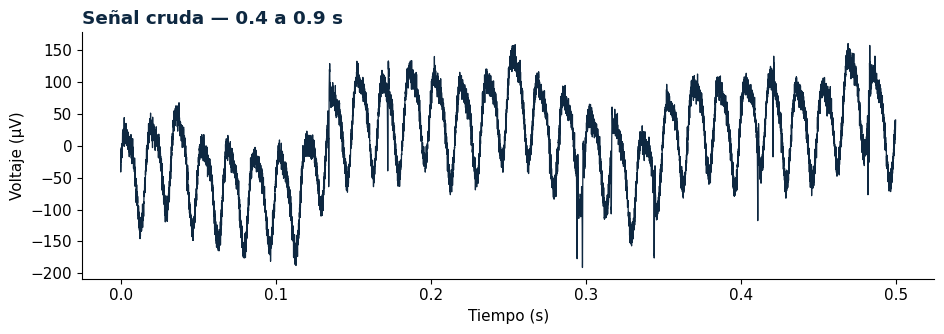

In [13]:
def ver(x, titulo, t0=0.4, t1=0.9, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1 (en segundos)."""
    # tu código aquí: máscara de la ventana de tiempo, plot, título y ejes CON UNIDADES

    m = (t >= t0) & (t < t1)                  # máscara: True donde el tiempo cae en la ventana
    plt.figure()
    plt.plot(t[m], x[m], color=color, lw=0.9)   # ¿qué va en el eje x y qué en el eje y?
    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("Tiempo (s)")                    # unidades: segundos
    plt.ylabel("Voltaje (µV)")                   # unidades: microvoltios

ver(cruda, "Señal cruda — 0.4 a 0.9 s", t0=0.0, t1=0.5)


✅ **Revisa tu figura a ojo.** Debe cumplir las cuatro cosas:

- [ ] Se ve **medio segundo** de registro, no los dos segundos completos.
- [ ] El eje horizontal dice *tiempo (s)* y el vertical *voltaje (µV)*.
- [ ] Se ve una **oscilación regular de fondo**, muy marcada.
- [ ] Se alcanzan a adivinar unos picos rápidos hacia abajo, montados sobre esa oscilación.

Si alguna falla, arregla la función antes de seguir: todo lo que viene la usa.

**Pregunta 1.** Compara esta figura con la señal limpia de la Sesión 3.

- ¿Puedes contar las espigas a ojo, como hiciste la semana pasada? ¿Por qué no?
- La oscilación de fondo se repite con un período muy regular. Estímalo a ojo con la
  regla del eje x y conviértelo a frecuencia (`f = 1/período`). ¿Qué número te da? (Periodo = tiempo que tarda en completar un ciclo u oscilación completa)
- ¿Ese número te parece de origen **biológico** o **instrumental**?

_Escribe tu respuesta aquí:_

Hay alrededor de 10 spikes pero no es muy clara la identificación porque el ruido de otras neuronas opaca la señal.

La frecuencia de la oscilación me dio 62,5 Hz, por lo que puedo intuir que se trata de ruido de la red electrica.


---
## 3 · Diagnosticar el ruido: el espectro de potencia

Mirar la señal en el tiempo te dice que *hay* algo raro. El **espectro de potencia** te
dice **qué** es: cuánta energía tiene la señal en cada frecuencia.

Es la herramienta de diagnóstico. Se mira **antes** de filtrar nada, porque un filtro que
no necesitas también deforma la señal.

Qué vas a buscar en él:

- un **pico angosto** en una frecuencia exacta → algo instrumental (la red eléctrica);
- **energía en las frecuencias bajas** (< 50 Hz) → el LFP;
- **energía entre 300 y 3000 Hz** → las espigas;
- un **piso plano** que nunca baja → ruido térmico, presente en todas las frecuencias.

### ✍️ Ejercicio 2 — Escribe tu prompt

Necesitas una función `espectro()`. Especificación:

| | |
|---|---|
| **Entradas** | `x` (array de voltaje), `etiqueta` (título), `fmax=500` (frecuencia máxima a mostrar), `fs` (frecuencia de muetreo) |
| **Salida** | dos arrays: `f` (frecuencias, Hz) y `P` (potencia en cada frecuencia) |
| **Cómo** | con `scipy.signal.welch`, usando `nperseg=8192`; graficar solo hasta `fmax`, con el **eje y en escala logarítmica** (`plt.semilogy`), ejes rotulados con unidades y el título a la izquierda |

Antes de escribirlo, repasa los **5 elementos**. Un prompt que solo diga *"hazme un
espectro"* te va a devolver algo que no encaja con estos datos.

💡 Pregúntale también **por qué** el eje y va en escala logarítmica. Vas a necesitar la
respuesta en la Pregunta 2.

_Escribe aquí el prompt que le vas a dar a la IA:_

>Estoy trabajando en Python desde Google Colab y utilizo únicamente las librerías `numpy`, `matplotlib` y `scipy.signal`. Tengo una señal cruda creada artificialmente que contiene ruido de LFP, spikes de neuronas cercanas, ruido térmico y ruido de la red eléctrica a 60 Hz. Necesito que definas una función llamada `espectro()` que calcule y grafique el espectro de potencia de la señal utilizando `scipy.signal.welch`. La función debe recibir como entradas `x` (array de voltaje), `etiqueta` (texto que se utilizará como título de la gráfica), `fmax=500` (frecuencia máxima que se mostrará en el eje x) y `fs` (frecuencia de muestreo en Hz), y debe devolver dos arrays: `f`, que contenga las frecuencias en Hz, y `P`, que contenga la potencia correspondiente a cada frecuencia. El cálculo mediante `scipy.signal.welch` debe utilizar obligatoriamente `nperseg=8192`; posteriormente, la gráfica debe mostrar únicamente las frecuencias entre 0 y `fmax`, utilizar `plt.semilogy()` para representar la potencia en el eje y en escala logarítmica, incluir etiquetas claras para ambos ejes con sus respectivas unidades y utilizar `etiqueta` como título de la gráfica, alineado a la izquierda. El código debe estar completamente documentado con comentarios claros que expliquen cada paso, debe ser apropiado para ejecutarse directamente en Google Colab y no utilizar ninguna librería adicional a `numpy`, `matplotlib` y `scipy.signal`.


_¿Qué línea del código que te dio no entiendes? Pregúntale en la misma conversación:
"¿qué hace esta línea:f, P = welch(x, fs=fs, nperseg=8192)?" y anota la respuesta en una frase: Es la función que calcula el espectro de potencia usando el metodo welch. Toma el array de voltaje, frecuencia de muestreo, muestras por segundo. Retorna son arrays. f, son las frecuencias de cada punto del espectro; p, son las potencias que le corresponden a cada espectro.

>

Pico dominante entre 40 y 200 Hz: 61.0 Hz
Resolución del espectro: 2.441 Hz
fs / nperseg = 2.441 Hz


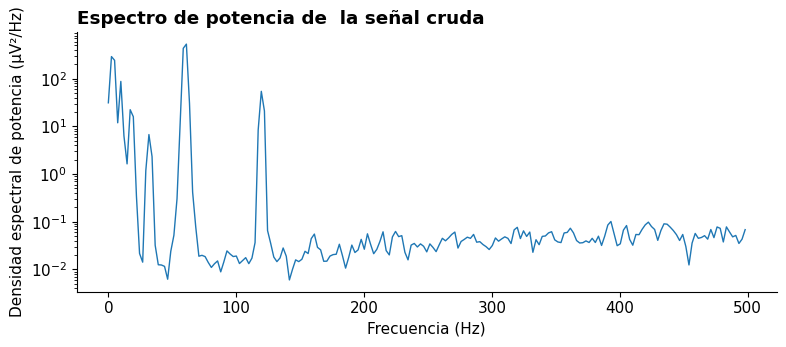

In [14]:
# Escribe aquí tu función espectro() y llámala sobre la señal cruda.
# Al final deben quedar definidas estas dos variables:
from scipy.signal import welch

def espectro(x, etiqueta, fmax=500, fs=None):
    """
    Calcula y grafica el espectro de potencia de una señal usando el método de Welch.

    Parámetros
    ----------
    x : np.ndarray
        Voltaje de la señal (µV u otra unidad consistente).
    etiqueta : str
        Texto que se usa como título de la gráfica.
    fmax : float
        Frecuencia máxima a mostrar en el eje x, en Hz.
    fs : float
        Frecuencia de muestreo, en Hz.

    Devuelve
    -------
    f : np.ndarray
        Frecuencias, en Hz.
    P : np.ndarray
        Densidad espectral de potencia en cada frecuencia.
    """

    # --- 1. Calcular el espectro de potencia con el método de Welch ---------
    # Welch divide la señal en segmentos (de 'nperseg' muestras cada uno,
    # con solape), calcula el espectro de cada segmento y los promedia.
    # Eso reduce el ruido en la estimación, a cambio de perder algo de
    # resolución en frecuencia -- el compromiso clásico de este método.
    # nperseg=8192 fijo, como pide el enunciado.
    f, P = welch(x, fs=fs, nperseg=8192)

    # --- 2. Quedarse solo con las frecuencias que se van a graficar ---------
    # welch() devuelve frecuencias desde 0 Hz hasta fs/2 (Nyquist), pero
    # normalmente solo interesa ver hasta unos cientos de Hz -- el resto
    # comprimiría la parte relevante de la gráfica.
    m = f <= fmax
    f_graficar = f[m]
    P_graficar = P[m]

    # --- 3. Graficar --------------------------------------------------------
    plt.figure(figsize=(8, 3.6))

    # semilogy: eje y en escala logarítmica. La potencia de una señal
    # biológica suele abarcar varios órdenes de magnitud entre frecuencias
    # (el LFP de baja frecuencia es mucho más potente que el ruido de alta
    # frecuencia); en escala lineal esas diferencias no se verían, en
    # escala log sí se distinguen los picos y valles.
    plt.semilogy(f_graficar, P_graficar, lw=1.0)

    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Densidad espectral de potencia (µV²/Hz)")
    plt.title(etiqueta, fontweight="bold", loc="left")
    plt.tight_layout()

    return f, P
f, P= espectro(cruda, "Espectro de potencia de  la señal cruda", fmax=500, fs=FS) #Llama tu función acá

# Esta línea te dice cuál es la frecuencia con más potencia entre 40 y 200 Hz:
m = (f > 40) & (f < 200)
pico = float(f[m][np.argmax(P[m])])
print(f"Pico dominante entre 40 y 200 Hz: {pico:.1f} Hz")
resolucion = f[1] - f[0]
print(f"Resolución del espectro: {resolucion:.3f} Hz")

# comprobación: la resolución teórica es fs / nperseg
print(f"fs / nperseg = {FS/8192:.3f} Hz")

In [15]:
# ✅ VERIFICACIÓN — ejercicio 2
revisar("espectro() devuelve dos arrays del mismo tamaño",
        len(f) == len(P) and len(f) > 100,
        "welch devuelve (frecuencias, potencias); tienes que retornar las dos")
revisar("las frecuencias llegan hasta Nyquist (10 000 Hz)",
        f.max() > 9000,
        "grafica solo hasta fmax, pero calcula el espectro completo: no recortes lo que retornas")
revisar("el pico dominante está en la red eléctrica (~60 Hz)",
        55 < pico < 65,
        "si te da otra cosa, revisa que le pasaste FS a welch y no el valor por defecto")
revisar("la potencia en 60 Hz es mucho mayor que la del LFP en 9 Hz",
        pot(cruda, 55, 65) > 5 * pot(cruda, 5, 15))

  OK    espectro() devuelve dos arrays del mismo tamaño
  OK    las frecuencias llegan hasta Nyquist (10 000 Hz)
  OK    el pico dominante está en la red eléctrica (~60 Hz)
  OK    la potencia en 60 Hz es mucho mayor que la del LFP en 9 Hz


**Pregunta 2.**

- El pico no cae exactamente en 60.0 Hz. Mira cuánto vale `f[1] - f[0]`: esa es la
  **resolución** de tu espectro. ¿Explica la diferencia?
- ¿Por qué el eje y va en escala logarítmica? Vuelve a graficar con `plt.plot` en vez de
  `plt.semilogy` y describe qué dejas de ver.
- Además del pico grande hay otro más pequeño al doble de la frecuencia. ¿Cómo se llama
  y de dónde sale?

_Escribe tu respuesta aquí:_

La resolución del espectro es 2.441Hz. El espectro no toma todos los valores sino que se organiza por bins. En ese sentido, la resolución seria el paso entre las frecuencias que estan espaciadas equitativamente.60 sufre un spectral leakage al no caer en un valor exacto por lo que su valor se aproxima al valor siguiente.

Porque la diferencia entre los datos son varios ordenes de magnitud, lo que causa la grafica se extienda mucho y que no sean visibles todos los valores. La escala logaritmica logra que las multiplicaciones sean sumas y convierte factores en distancias iguales en el eje.

Seria un armonico de la misma señal de la red electrica.

---
## 4 · Quitar los 60 Hz: el filtro notch

Un *notch* (muesca) elimina una franja **muy angosta** de frecuencias y deja el resto casi
intacto. Es el filtro correcto para el ruido de red, porque el problema está en una
frecuencia exacta y no en una banda.

⚠️ Úsalo **solo si el ruido de red está presente en el espectro**. Aplicar un notch donde
no hay nada que quitar también deforma la señal.

### 📋 Ejercicio 3 — Pega este prompt

Cópialo **tal cual** en ChatGPT o Claude. Lee la respuesta completa antes de usarla.

> Trabajo en Python con numpy y scipy. Tengo un array `cruda` con el voltaje (en µV) de un
> registro extracelular muestreado a 20000 Hz, contaminado con ruido de red eléctrica en
> 60 Hz y su armónico en 120 Hz. Escríbeme una función `notch(x, f0, Q=30)` que use
> `scipy.signal.iirnotch` para diseñar el filtro y `scipy.signal.filtfilt` para aplicarlo.
> Explícame qué controla el parámetro `Q` y por qué en análisis de espigas se usa
> `filtfilt` y no `lfilter`. Rotula todo con unidades y explícame cada línea.

Después, contesta antes de correr nada: **¿el código que te dio sirve, o le sobra o le
falta algo?** Fíjate sobre todo en si le pasa la frecuencia de muestreo al diseñar el
filtro — es el error más común.

Q es un parametro que controla que tan grande es la función que voy a retirar. Se calcula dividiendo la frecuencia a eliminar entre el ancho de banda en los puntos a -3 dB alrededor de f0.

Se usa filtfilt y no lfilter porque el primero corre en las dos direcciones por lo que el retraso que produce el filtro se cancela

<Figure size 1100x320 with 0 Axes>

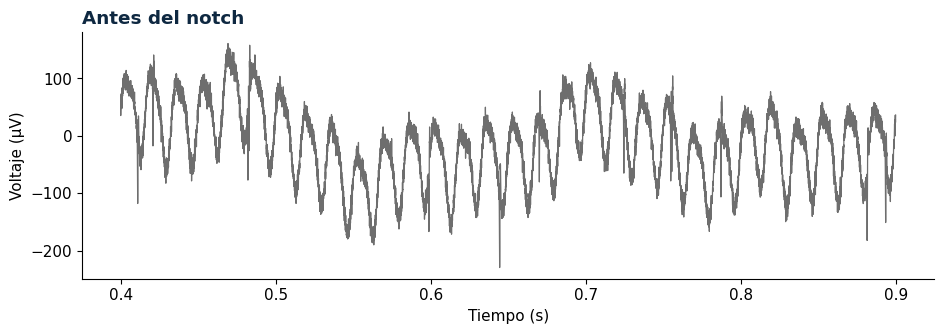

<Figure size 1100x320 with 0 Axes>

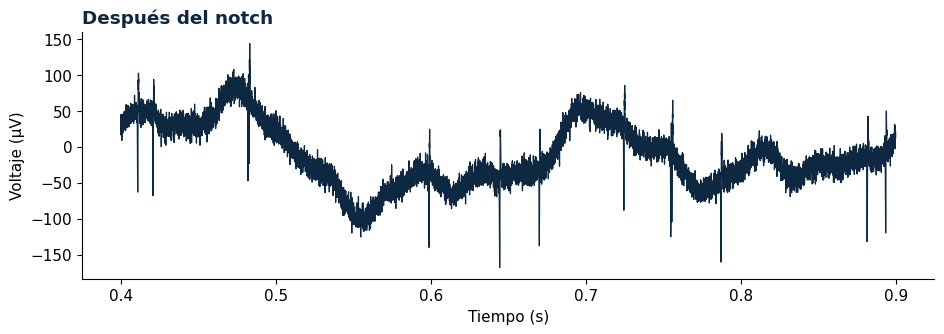

In [16]:
# Pega aquí la función notch() (la de la IA, corregida por ti) y aplícala.
# Recuerda que hay DOS frecuencias que quitar: 60 Hz y su armónico.

from scipy.signal import iirnotch, filtfilt


def notch(x, f0, Q=30, fs=FS):
    """
    Elimina una frecuencia específica (y una banda angosta a su alrededor)
    de la señal, usando un filtro notch IIR aplicado sin desfase temporal.

    Parámetros
    ----------
    x : np.ndarray
        Señal de entrada, en µV.
    f0 : float
        Frecuencia central a eliminar, en Hz (por ejemplo, 60.0 o 120.0).
    Q : float
        Factor de calidad del filtro: qué tan angosta es la banda eliminada.
    fs : float
        Frecuencia de muestreo, en Hz.

    Devuelve
    -------
    np.ndarray
        La señal filtrada, del mismo largo que x, en µV.
    """

    # --- 1. Diseñar el filtro ------------------------------------------------
    # iirnotch() no filtra nada todavía: solo CALCULA los coeficientes del
    # filtro (b: numerador, a: denominador) que, al aplicarse, van a anular
    # la frecuencia f0 y dejar casi intacto el resto del espectro.
    b, a = iirnotch(f0, Q, fs)

    # --- 2. Aplicar el filtro, sin desfase temporal --------------------------
    # filtfilt aplica el filtro dos veces: una vez hacia adelante en el
    # tiempo, y otra vez hacia atrás sobre el resultado. Eso cancela
    # cualquier desfase (retraso) que el filtro introduciría si se
    # aplicara una sola vez -- ver la explicación más abajo.
    y = filtfilt(b, a, x)

    return y
sin_red = notch(cruda, 60,  Q=30, fs=FS )
sin_red120 = notch(sin_red, 120, Q=30, fs=FS)

# Comparación visual: antes y después
plt.figure(); ver(cruda,   "Antes del notch",  color=GRAY)
plt.figure(); ver(sin_red120, "Después del notch", color=NAVY)

In [17]:
# ✅ VERIFICACIÓN — ejercicio 3
caida_60 = 10*np.log10(pot(cruda,  55,  65) / pot(sin_red,  55,  65))
caida_120 = 10*np.log10(pot(cruda, 115, 125) / pot(sin_red120, 115, 125))
cambio_lento = abs(10*np.log10(pot(cruda, 5, 15) / pot(sin_red120, 5, 15)))
print(f"caída en 60 Hz: {caida_60:.1f} dB   ·   caída en 120 Hz: {caida_120:.1f} dB")
print(f"cambio en la banda del LFP (5-15 Hz): {cambio_lento:.2f} dB\n")

revisar("sin_red tiene el mismo número de muestras que cruda",
        len(sin_red) == len(cruda),
        "filtfilt devuelve una señal de la misma longitud; no recortes nada")
revisar("el notch bajó los 60 Hz al menos 10 dB",
        caida_60 > 10,
        "revisa que le pasaste fs=20000 a iirnotch; sin eso el filtro queda en la frecuencia equivocada")
revisar("también quitaste el armónico de 120 Hz",
        caida_120 > 10,
        "hay que aplicar el notch dos veces, una por cada frecuencia")
revisar("el notch NO tocó la banda del LFP",
        cambio_lento < 1.0,
        "si el LFP también cayó, tu Q es demasiado bajo: el notch quedó muy ancho")

caída en 60 Hz: 24.6 dB   ·   caída en 120 Hz: 30.5 dB
cambio en la banda del LFP (5-15 Hz): 0.00 dB

  OK    sin_red tiene el mismo número de muestras que cruda
  OK    el notch bajó los 60 Hz al menos 10 dB
  OK    también quitaste el armónico de 120 Hz
  OK    el notch NO tocó la banda del LFP


**Pregunta 3.** Prueba dos cosas y describe qué pasa:

- Aplica un notch en **9 Hz**, una frecuencia donde sí hay señal biológica. Grafica el
  antes y el después y di qué le pasó al LFP.
- Vuelve al notch de 60 Hz pero con `Q = 2`. ¿Qué es Q? Grafica el espectro resultante. ¿Qué se
  llevó por delante?

Con eso, contesta: **¿por qué el diagnóstico va antes del filtrado?**

_Escribe tu respuesta aquí:_

Cuando se cambia la frecuencia que se va a descartar, el filtro no revela un cambio evidente. Deberia disminuir la amplitud de la grafica porque se pierde una de las ondas más dominantes del LFP.
El valor q es inversamente proporcional al ancho de banda de las frecuencias se van a recortar por lo que un Q = 2 recortaria una fracción muy grande de frecuencias.



---
## 5 · Separar las dos bandas

La señal sin ruido de red sigue siendo una **mezcla** de dos cosas que ocurren a
velocidades distintas:

- por **debajo de ~300 Hz**, la actividad lenta de toda la población: el **LFP**;
- por **encima de ~300 Hz**, sobre todo los potenciales de acción: la **banda AP**.

El corte en 300 Hz es una convención, no una ley de la naturaleza. En la Pregunta 4 vas a
ver qué tan arbitrario es.

### ✍️ Ejercicio 4 — Escribe tu prompt

Necesitas **una sola** función que sirva para los dos casos. Especificación:

| | |
|---|---|
| **Entradas** | `x` (señal), `low=None` (corte del pasa-bajos), `high=None` (corte del pasa-altos), `orden=4` |
| **Salida** | la señal filtrada, del mismo tamaño que `x` |
| **Cómo** | filtro **Butterworth**; si solo se da `low`, es pasa-bajos; si solo se da `high`, es pasa-altos; si se dan los dos, pasa-banda |
| **Exigencias** | usar `output="sos"` y aplicarlo con `sosfiltfilt` (fase cero, para que **no se desplacen** los tiempos de las espigas); normalizar las frecuencias por Nyquist |

Estas dos exigencias no son un capricho:

- **fase cero** — un filtro normal retrasa la señal, y ese retraso depende de la
  frecuencia. Si filtras así, las espigas se te mueven en el tiempo y todo lo que midas
  después queda corrido. `sosfiltfilt` pasa el filtro hacia adelante y hacia atrás, y los
  dos retrasos se cancelan.
- **`sos`** — con órdenes altos o cortes muy bajos, los coeficientes `b, a` se vuelven
  numéricamente inestables y el filtro devuelve basura. Las secciones de segundo orden no.

Pídele a la IA que te explique cada una de las dos.

_Escribe aquí tu prompt:_

> Estoy trabajando en Python desde Google Colab y utilizo las librerías numpy y scipy.signal. Necesito que definas una función para filtrar una señal x utilizando un filtro Butterworth, con las siguientes entradas: x (señal), low=None (frecuencia de corte del pasa-bajos), high=None (frecuencia de corte del pasa-altos) y orden=4 (orden del filtro). La función debe devolver como salida la señal filtrada, manteniendo exactamente el mismo tamaño que x. El comportamiento del filtro debe depender de las frecuencias proporcionadas: si únicamente se especifica low, debe aplicar un filtro pasa-bajos; si únicamente se especifica high, debe aplicar un filtro pasa-altos; y si se especifican tanto low como high, debe aplicar un filtro pasa-banda. El filtro debe diseñarse con scipy.signal.butter, utilizando obligatoriamente output="sos", y debe aplicarse mediante scipy.signal.sosfiltfilt para realizar un filtrado de fase cero, evitando así que las espigas se desplacen temporalmente respecto a su posición original. Las frecuencias de corte deben normalizarse respecto a la frecuencia de Nyquist (fs/2), por lo que la función debe recibir también fs como frecuencia de muestreo. El código debe estar claramente documentado, explicar qué ocurre en cada tipo de filtro y no utilizar librerías adicionales.

_Anota en una frase qué te respondió sobre Nyquist:_

>Nyquist es la frecuencia máxima que se puede representar correctamente en una señal muestreada, y es igual a la mitad de la frecuencia de muestreo

<Figure size 1100x320 with 0 Axes>

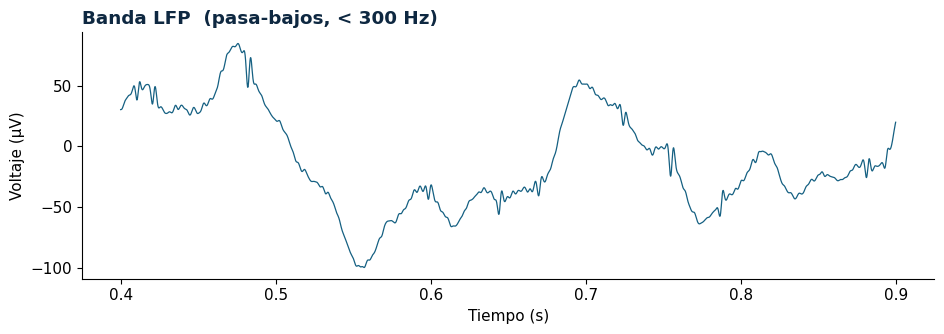

<Figure size 1100x320 with 0 Axes>

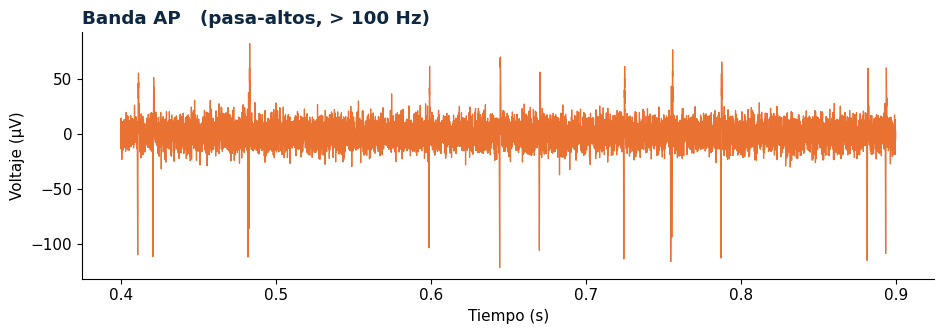

<Figure size 1100x320 with 0 Axes>

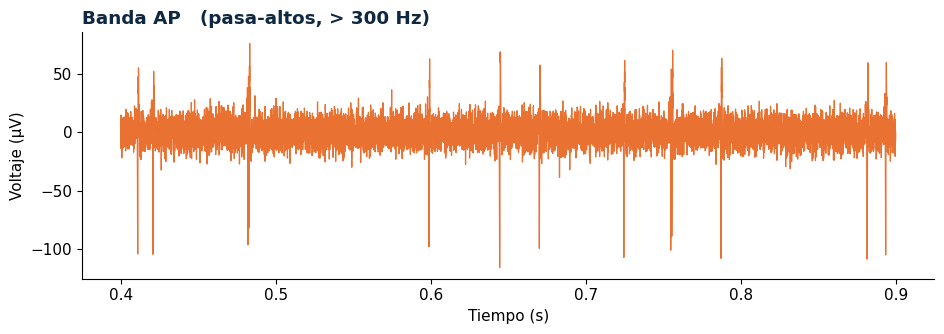

<Figure size 1100x320 with 0 Axes>

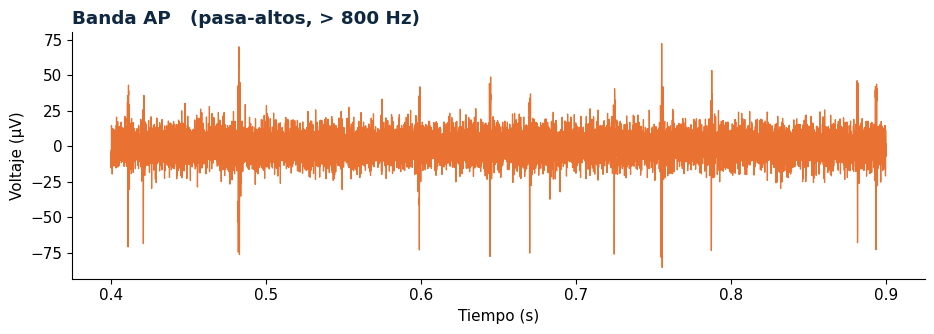

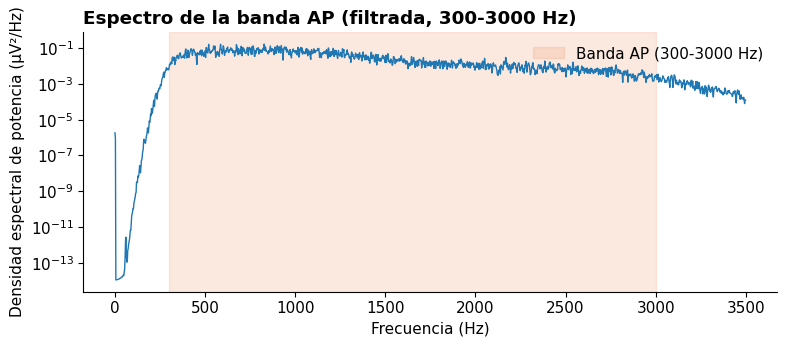

In [18]:
# Escribe aquí tu función filtrar() y úsala para obtener las dos bandas.
from scipy.signal import butter, sosfiltfilt


def filtrar(x, low=None, high=None, orden=4, fs=None):
    """
    Filtra una señal con un filtro Butterworth (pasa-bajos, pasa-altos o
    pasa-banda, según qué frecuencias de corte se den), aplicado sin
    desfase temporal.

    Parámetros
    ----------
    x : np.ndarray
        Señal a filtrar, en µV.
    low : float o None
        Frecuencia de corte del pasa-bajos, en Hz. Si se da SOLO esta,
        el filtro deja pasar todo lo que está por DEBAJO de esta frecuencia.
    high : float o None
        Frecuencia de corte del pasa-altos, en Hz. Si se da SOLO esta,
        el filtro deja pasar todo lo que está por ENCIMA de esta frecuencia.
    orden : int
        Orden del filtro: qué tan abrupta es la transición entre lo que
        se deja pasar y lo que se atenúa. Más orden = corte más marcado.
    fs : float
        Frecuencia de muestreo, en Hz.

    Devuelve
    -------
    np.ndarray
        La señal filtrada, en µV, con el mismo largo que x.
    """

    # --- 1. Validaciones -----------------------------------------------------
    if fs is None:
        raise ValueError("fs es obligatorio")
    if low is None and high is None:
        raise ValueError("hay que dar al menos 'low' o 'high'")

    nyq = fs / 2    # frecuencia de Nyquist, en Hz: la máxima frecuencia representable

    # --- 2. Diseñar el filtro según qué frecuencias se dieron -----------------

    if low is not None and high is not None:
        # PASA-BANDA: deja pasar solo lo que está ENTRE low y high.
        # Se usa cuando querés aislar una banda específica del espectro
        # (por ejemplo, la banda de AP entre 300 y 3000 Hz), descartando
        # tanto las frecuencias más bajas como las más altas que esa banda.
        Wn = [low / nyq, high / nyq]     # normalizado: 1.0 = Nyquist
        sos = butter(orden, Wn, btype="band", output="sos")

    elif low is not None:
        # PASA-BAJOS: deja pasar todo lo que está POR DEBAJO de 'low',
        # y atenúa todo lo que está por encima. Se usa para aislar
        # componentes lentas de la señal (por ejemplo, el LFP).
        Wn = low / nyq
        sos = butter(orden, Wn, btype="low", output="sos")

    else:  # solo 'high'
        # PASA-ALTOS: deja pasar todo lo que está POR ENCIMA de 'high',
        # y atenúa todo lo que está por debajo. Se usa para aislar
        # componentes rápidas (por ejemplo, quitar el LFP y quedarse
        # con la banda de potenciales de acción).
        Wn = high / nyq
        sos = butter(orden, Wn, btype="high", output="sos")


    # --- 3. Aplicar el filtro, sin desfase temporal ----------------------------
    # sosfiltfilt (la versión de filtfilt para filtros en formato 'sos')
    # aplica el filtro dos veces -- adelante y atrás -- cancelando el
    # desfase que introduciría una sola pasada. Así, las espigas no se
    # desplazan en el tiempo respecto a su posición real.
    return sosfiltfilt(sos, x)

# Ojo: las dos bandas se sacan de la señal que YA no tiene ruido de red.
# Si las sacas de `cruda`, los 60 Hz se te vuelven a colar en el LFP.
LFP = filtrar(sin_red120,low=300 , fs=FS)     # pasa-bajos: todo lo que va por debajo de 300 Hz
AP100  = filtrar(sin_red120,high=100, fs=FS)     # pasa-altos: todo lo que va por encima de 100 Hz
AP300  = filtrar(sin_red120,high=300, fs=FS)     # pasa-altos: todo lo que va por encima de 300 Hz
AP800  = filtrar(sin_red120,high=800, fs=FS)     # pasa-altos: todo lo que va por encima de 800 Hz


plt.figure(); ver(LFP, "Banda LFP  (pasa-bajos, < 300 Hz)", color=TEAL)
plt.figure(); ver(AP100,  "Banda AP   (pasa-altos, > 100 Hz)", color=ORANGE)
plt.figure(); ver(AP300,  "Banda AP   (pasa-altos, > 300 Hz)", color=ORANGE)
plt.figure(); ver(AP800,  "Banda AP   (pasa-altos, > 800 Hz)", color=ORANGE)
# 1) Aislar la banda AP con el filtro que armamos (pasa-banda 300-3000 Hz)
banda_ap = filtrar(sin_red120, low=300, high=3000, fs=FS)

# 2) Graficar el espectro de la señal YA FILTRADA
f, P = espectro(banda_ap, "Espectro de la banda AP (filtrada, 300-3000 Hz)", fmax=3500, fs=FS)

# 3) Sombrear, sobre esa misma figura, el rango que define la banda AP
plt.axvspan(300, 3000, color=ORANGE, alpha=0.15, label="Banda AP (300-3000 Hz)")
plt.legend(frameon=False, loc="upper right")

In [22]:
# ✅ VERIFICACIÓN — ejercicio 4
print(f"desviación estándar   ·   sin_red: {sin_red.std():6.1f} µV"
      f"   ·   LFP: {LFP.std():6.1f} µV   ·   AP: {AP300.std():6.1f} µV\n")

revisar("las dos bandas tienen el mismo tamaño que la señal original",
        len(LFP) == len(sin_red) and len(AP300) == len(sin_red))
revisar("el LFP se quedó con lo lento",
        pot(LFP, 0, 50) > 100 * pot(LFP, 1000, 5000),
        "si el LFP todavía tiene energía en frecuencias altas, el filtro es pasa-altos, no pasa-bajos")
revisar("la banda AP botó lo lento",
        pot(AP300, 0, 50) < 0.01 * pot(sin_red, 0, 50),
        "revisa que 'high' se usa con btype='high'")
revisar("la banda AP conservó las espigas (300-3000 Hz)",
        pot(AP300, 300, 3000) > 10 * pot(LFP, 300, 3000))
revisar("el LFP es más grande que la banda AP",
        LFP.std() > 2 * AP300.std(),
        "en un registro extracelular casi toda la varianza está en el LFP")

desviación estándar   ·   sin_red:   49.9 µV   ·   LFP:   46.2 µV   ·   AP:   12.1 µV

  OK    las dos bandas tienen el mismo tamaño que la señal original
  OK    el LFP se quedó con lo lento
  OK    la banda AP botó lo lento
  OK    la banda AP conservó las espigas (300-3000 Hz)
  OK    el LFP es más grande que la banda AP


**Pregunta 4.** Repite el filtrado moviendo el corte a **100 Hz** y a **800 Hz**, y
grafica la banda AP en los tres casos (100, 300, 800).

- ¿Qué le pasa a la **forma** de las espigas cuando el corte sube a 800 Hz?
s
- Con el corte en 100 Hz, ¿qué se cuela en la banda AP que no debería estar ahí?
- Si tuvieras que justificar el corte de 300 Hz en un artículo, ¿qué dirías?

_Escribe tu respuesta aquí:_
En teoria un pasa altos con un filtro muy grande pierde parte de la información y el spike se veria más angosto, sin embargo en la grafica solo se que la amplitud sube.
Con un filtro de 100Hz empieza a haber deriva lenta.

Se eligio el filtro en 300 Hz porque separa razonablemente bien dos procesos fisiológicos con contenido espectral distinto: el LFP, cuya potencia se concentra predominantemente por debajo de esa frecuencia, y los potenciales de acción, cuya energía —dada su corta duración (~1-2 ms)— se extiende principalmente por encima de ella. Cortes más bajos (p. ej. 100 Hz) dejan pasar contenido residual de LFP hacia la banda de análisis de espigas, mientras que cortes más altos (p. ej. 800 Hz) comienzan a eliminar componentes espectrales propios de la forma de la espiga, distorsionando su morfología. 300 Hz es el punto de la literatura estándar en electrofisiología extracelular que minimiza ambos tipos de error simultáneamente, y fue validado empíricamente comparando visualmente la forma de las espigas y el espectro de potencia resultante a distintos valores de corte.

---
## 6 · Detectar espigas sobre la banda AP

Ya conoces el procedimiento de la Sesión 3: umbral robusto, cruces, período muerto. Lo
único que cambia es **sobre qué señal lo aplicas**.

El umbral no se pone a ojo: se calcula a partir del ruido de la propia señal. La estimación
robusta que ya usaste (Quiroga et al., 2004) es

$$\hat{\sigma} = \frac{\text{mediana}(|x|)}{0.6745}, \qquad \text{umbral} = -k\,\hat{\sigma}$$

### ✏️ Ejercicio 5 — Completa el código

Aquí hay una trampa. Piensa antes de llenar el primer hueco: **¿sobre cuál de las tres
señales (`cruda`, `sin_red`, `AP`) debes estimar el ruido?** La celda de verificación te
va a delatar si escogiste mal.

sigma del ruido ≈ 9.2 µV
umbral = -6 × sigma = -55.3 µV


<Figure size 1100x320 with 0 Axes>

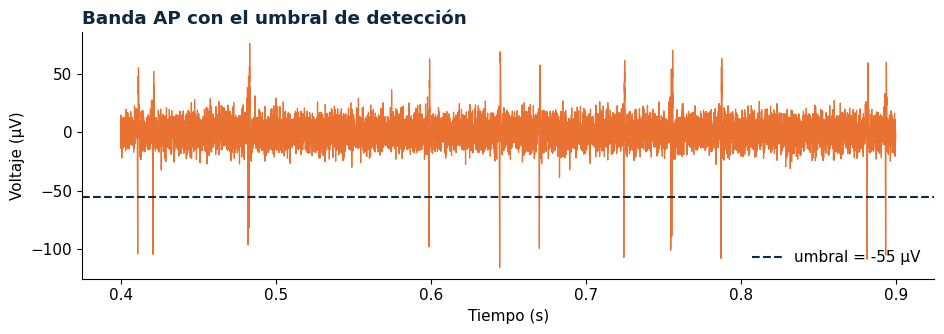

In [23]:
sigma  = np.median(np.abs(AP300)) / 0.6745    # ¿sobre qué señal? piénsalo
k      = 6                            # cuántas sigmas de distancia exigimos
umbral = -k*sigma                               # en µV, y negativo

print(f"sigma del ruido ≈ {sigma:.1f} µV")
print(f"umbral = -{k} × sigma = {umbral:.1f} µV")

plt.figure()
ver(AP300, "Banda AP con el umbral de detección", color=ORANGE)
plt.axhline(umbral, color=NAVY, ls="--", lw=1.5, label=f"umbral = {umbral:.0f} µV")
plt.legend(frameon=False, loc="lower right")

In [25]:
# ✅ VERIFICACIÓN — ejercicio 5
print("Para comparar, la sigma robusta de cada señal:")
for nombre, s in [("cruda", cruda), ("sin_red", sin_red), ("LFP", LFP), ("AP", AP300)]:
    print(f"   {nombre:8}  {np.median(np.abs(s))/0.6745:7.1f} µV")
print("El ruido térmico que le pusimos a la señal tiene sigma = 9.0 µV.\n")

revisar("estimaste el ruido sobre la banda AP, no sobre la señal cruda",
        7 < sigma < 12,
        "sobre la señal cruda el LFP infla la estimación diez veces: el umbral queda inservible")
revisar("el umbral es negativo",
        umbral < 0,
        "las espigas extracelulares son picos hacia abajo")
revisar("el umbral es exactamente -k veces sigma",
        abs(umbral + k*sigma) < 0.5)
revisar("k está en el rango razonable para espigas (3 a 6)",
        3 <= k <= 6,
        "con k muy bajo detectas ruido; con k muy alto pierdes las espigas pequeñas")

Para comparar, la sigma robusta de cada señal:
   cruda        75.1 µV
   sin_red      53.4 µV
   LFP          51.6 µV
   AP            9.2 µV
El ruido térmico que le pusimos a la señal tiene sigma = 9.0 µV.

  OK    estimaste el ruido sobre la banda AP, no sobre la señal cruda
  OK    el umbral es negativo
  OK    el umbral es exactamente -k veces sigma
  OK    k está en el rango razonable para espigas (3 a 6)


### ✍️ Ejercicio 6 — Escribe tu prompt

Ahora la función `detectar()`. **Ya la escribiste en la Sesión 3**: ábrela, pégala aquí y
adáptala si hace falta. Copiar y adaptar tu propio código es exactamente lo que se hace en
un laboratorio real — no es hacer trampa, es tener un pipeline.

Si no la tienes a mano, escribe el prompt tú. Especificación:

| | |
|---|---|
| **Entradas** | `x` (array de voltaje), `umbral` (número negativo), `muerto_ms=2.0`, `fs=FS` |
| **Salida** | un array de **índices** (no de tiempos), uno por espiga detectada |
| **Cómo** | encontrar los índices donde `x` está por debajo del umbral; tomar el primero; buscar el **mínimo** dentro de la ventana del período muerto; guardar ese índice; saltar al primer cruce que ocurra después de la ventana y repetir |

_reutilicé mi función de la Sesión 3

>

In [26]:
def detectar(x, umbral, muerto_ms=2.0, fs=FS):

    x = np.asarray(x)

    if x.ndim != 1:
        raise ValueError("x debe ser un array 1D")
    if fs <= 0:
        raise ValueError("fs debe ser mayor que 0")

    n = len(x)

    # Convertir 2 ms a número de muestras
    muerto_muestras = int(round(muerto_ms * fs / 1000))
    muerto_muestras = max(muerto_muestras, 1)

    # Índices donde la señal está por debajo del umbral
    candidatos = np.where(x < umbral)[0]

    if len(candidatos) == 0:
        return np.array([], dtype=int)

    spikes = []
    pos = 0

    while pos < len(candidatos):

        # Primer cruce disponible
        inicio = candidatos[pos]

        # Buscar el mínimo dentro de los siguientes 2 ms
        fin = min(inicio + muerto_muestras, n)

        ventana = x[inicio:fin]

        # Índice relativo del mínimo
        offset = np.argmin(ventana)

        # Índice absoluto del pico
        indice_spike = inicio + offset

        spikes.append(indice_spike)

        # IMPORTANTE:
        # el siguiente spike debe estar al menos 2 ms después
        # del pico que acabamos de detectar
        siguiente = indice_spike + muerto_muestras

        # Buscar el primer cruce que ocurra después de ese punto
        pos = np.searchsorted(candidatos, siguiente, side="left")

    return np.array(spikes, dtype=int)

idx        = detectar(AP300, umbral)     # índices de muestra
detectados = t[idx]                   # índices -> tiempos, en segundos
amplitudes = AP300[idx]                  # voltaje del pico de cada espiga, en µV

print("espigas detectadas:", len(idx), " | espigas simuladas:", len(tiempos_verdaderos))

espigas detectadas: 41  | espigas simuladas: 45


In [27]:
# ✅ VERIFICACIÓN — ejercicio 6
idx = np.asarray(idx)
revisar("detectar() devuelve índices enteros, no tiempos",
        idx.dtype.kind in "iu" and idx.max() < len(AP300),
        "los índices son posiciones en el array; los tiempos salen después, con t[idx]")
revisar("el número de detecciones es plausible (entre 35 y 55)",
        35 <= len(idx) <= 55,
        "si te salen cientos, no estás aplicando el período muerto; si te salen ~15, tu umbral es muy exigente")
revisar("todos los índices caen por debajo del umbral",
        bool(np.all(AP300[idx] < umbral)),
        "estás guardando el índice del cruce o del final de la ventana, no el del mínimo")
revisar("no hay dos detecciones separadas por menos del período muerto",
        bool(np.all(np.diff(detectados) >= 0.0019)),
        "después de detectar una espiga tienes que saltar 2 ms hacia adelante")
revisar("los índices salen ordenados en el tiempo",
        bool(np.all(np.diff(idx) > 0)))

  OK    detectar() devuelve índices enteros, no tiempos
  OK    el número de detecciones es plausible (entre 35 y 55)
  OK    todos los índices caen por debajo del umbral
  OK    no hay dos detecciones separadas por menos del período muerto
  OK    los índices salen ordenados en el tiempo


### ✏️ Ejercicio 7 — Completa el código

Una figura que muestre el resultado: la banda AP, la línea del umbral y un marcador sobre
el pico de cada espiga detectada.

Fíjate en la línea de `d`: selecciona **solo** las detecciones que caen dentro de la
ventana que estás graficando. Sin eso, matplotlib intenta dibujar marcadores fuera del eje
y la figura queda comprimida.

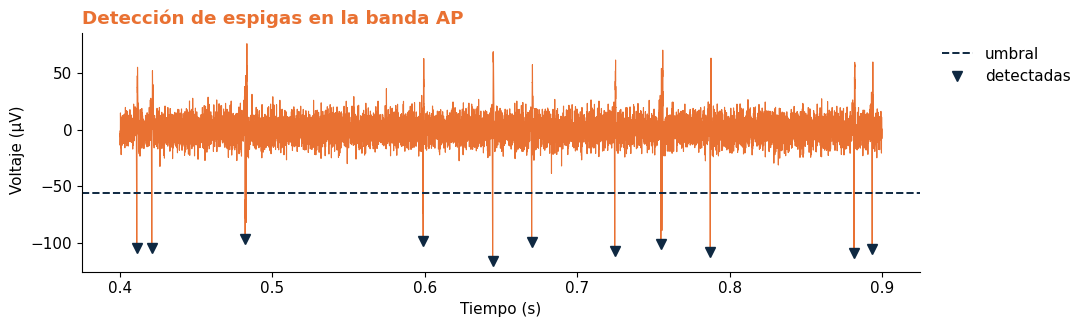

In [29]:
t0, t1 = 0.4, 0.9
m = (t >= t0) & (t < t1)
d = idx[(detectados >= t0) & (detectados < t1)]      # detecciones dentro de la ventana

plt.figure(figsize=(11, 3.4))
plt.plot(t[m], AP300[m], color=ORANGE, lw=0.8)
plt.axhline(umbral, color=NAVY, ls="--", lw=1.4, label="umbral")
plt.plot(t[d], AP300[d], "v", color=NAVY, ms=7, ls="none", label="detectadas")   # ¿tiempo y voltaje de qué?
plt.xlabel("Tiempo (s)"); plt.ylabel(" Voltaje (µV)")
plt.title("Detección de espigas en la banda AP", color=ORANGE, fontweight="bold", loc="left")
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()

✅ **Revisa tu figura a ojo:**

- [ ] Los triángulos caen **encima** del pico de cada espiga, no flotando ni desplazados.
- [ ] No hay ninguna espiga evidente sin su triángulo.
- [ ] No hay triángulos sobre puntos que claramente son ruido.
- [ ] Hay leyenda y los ejes tienen unidades.

**Pregunta 5.** Mira el número que imprimió la celda anterior: detectaste unas cuantas
espigas menos de las que se simularon.

- ¿Las que faltan son espigas **pequeñas** que no alcanzaron a cruzar el umbral, o espigas
  que llegaron **muy pegadas** a otra? Mira la figura antes de responder.
- Sube `k` a 6 y bájalo a 3. ¿En cuál de los dos casos detectas más? ¿Y en cuál de los dos
  confías más en lo que detectaste?

No hay que resolverlo hoy: **medir** cuántas acertaste y cuántas te inventaste es
justamente el tema del Taller 1.

_Escribe tu respuesta aquí:_
 Las espigas faltantes son muy pequeñas y no pasaron el umbral.Con un valor k de 6 hay menos falsos positivos por lo que confio más

---
## 7 · Comprobar: el filtrado separa, no inventa

Es la afirmación central de toda la sesión, y no hay que creerla: se comprueba.

Si el filtrado estuviera **inventando** señal, sumar las dos bandas no devolvería la
original. Vamos a sumarlas y medir la diferencia.

### ✏️ Ejercicio 8 — Completa el código

Error cuadrático medio:            0.131 µV
Amplitud típica de la señal:       47.8 µV
El error es el 0.27% de la señal


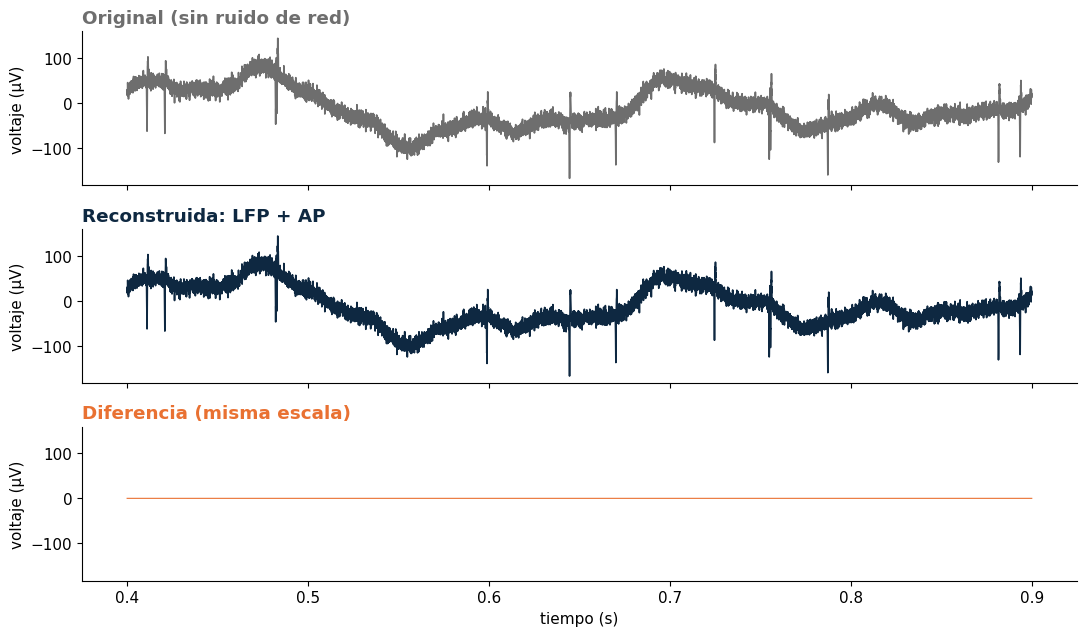

In [30]:
reconstruida = AP300 + LFP                                    # las dos bandas, sumadas
error = np.sqrt(np.mean((reconstruida - sin_red120)**2))            # ¿contra cuál señal comparas?

print(f"Error cuadrático medio:            {error:.3f} µV")
print(f"Amplitud típica de la señal:       {sin_red120.std():.1f} µV")
print(f"El error es el {100*error/sin_red120.std():.2f}% de la señal")

t0, t1 = 0.4, 0.9
m = (t >= t0) & (t < t1)

# sharey=True obliga a los tres paneles a usar la MISMA escala vertical.
# Sin eso, matplotlib le pone a cada panel su propia escala y la comparación engaña.
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True, sharey= True)

# Arriba: la señal original, la que queremos recuperar.
ax1.plot(t[m], sin_red120[m], color=GRAY, lw=1.2)
ax1.set_title("Original (sin ruido de red)", color=GRAY, fontweight="bold", loc="left")
ax1.set_ylabel("voltaje (µV)")

# En medio: la suma de las dos bandas. ¿Se parece a la de arriba?
ax2.plot(t[m], reconstruida[m], color=NAVY, lw=1.2)
ax2.set_title("Reconstruida: LFP + AP", color=NAVY, fontweight="bold", loc="left")
ax2.set_ylabel("voltaje (µV)")

# Abajo: la diferencia entre las dos. Si se ve plana, es porque el error es
# despreciable frente a la amplitud de la señal (y no porque cambiamos la escala).
ax3.plot(t[m], (reconstruida - sin_red120)[m], color=ORANGE, lw=0.8)
ax3.set_title("Diferencia (misma escala)", color=ORANGE, fontweight="bold", loc="left")
ax3.set_ylabel("voltaje (µV)"); ax3.set_xlabel("tiempo (s)")

plt.tight_layout()

In [31]:
# ✅ VERIFICACIÓN — ejercicio 8
revisar("el error es despreciable frente a la señal",
        error < 0.05 * sin_red.std(),
        "si el error es grande, revisa contra qué señal comparas: LFP+AP reconstruye sin_red, no cruda")
revisar("comparaste contra la señal correcta",
        np.sqrt(np.mean((reconstruida - sin_red)**2)) < np.sqrt(np.mean((reconstruida - cruda)**2)),
        "el notch se aplicó ANTES de separar las bandas, así que los 60 Hz ya no están en ninguna de las dos")
revisar("el panel de abajo está en la misma escala que el de arriba",
        ax2.get_ylim() == ax1.get_ylim(),
        "sin la misma escala la figura miente: cualquier diferencia parece enorme")

  OK    el error es despreciable frente a la señal
  OK    comparaste contra la señal correcta
  OK    el panel de abajo está en la misma escala que el de arriba


**Pregunta 6.** El error no es exactamente cero.
- Ahora repite la suma pero comparando `LFP + AP` contra `cruda`. ¿Cuánto vale el error?
  ¿Qué te dice esa diferencia sobre lo que hizo el notch?

_Escribe tu respuesta aquí:_

Con el set original de datos el error fue de 49.949 µV comparado con 0.131 µV de la señal con el filtro notch

---
## 8 · Subir la práctica a tu repositorio

Ya creaste tu repositorio `analisis-neuronal-insectos` en el **Lab 1**, con su README y su
carpeta `practicas/`. Hoy solo agregas un archivo más. Esa es la idea: el repositorio no se
rehace cada semana, **crece**. Al final del semestre será el historial completo de tu curso.

Si el repo te quedó privado o no alcanzaste a terminar el Bloque E del Lab 1, resuélvelo
primero (Lab 1, ejercicios G1–G2) y sigue desde aquí.

### Paso 1 — Nombra y guarda el cuaderno

Clic sobre el título, arriba a la izquierda, y renómbralo `Practica_S4_TuNombre.ipynb`.
Luego **Entorno de ejecución → Reiniciar y ejecutar todo** una última vez: se sube el
cuaderno **con las figuras ya dentro**.

### Paso 2 — Súbelo desde Colab, sin descargar nada

En el Lab 1 lo descargaste y lo arrastraste a GitHub. Hay un atajo que evita el viaje por
la carpeta de descargas:

1. **Archivo → Guardar una copia en GitHub**.
2. La primera vez, Colab te pide autorización en tu cuenta de GitHub → **Authorize**.
3. **Repositorio:** `tu-usuario/analisis-neuronal-insectos`  ·  **Rama:** `main`
4. **Ruta del archivo:** `practicas/Practica_S4_TuNombre.ipynb`
   *(escribe la ruta completa con la barra: si pones solo el nombre, el cuaderno queda
   suelto en la raíz del repositorio, no dentro de `practicas/`)*
5. **Mensaje del commit:** que se entienda sin contexto, como los del Lab 1. Por ejemplo:
   `Agregar Practica S4: notch de 60 Hz, separacion LFP/AP y conteo VP-FP-FN`
6. Marca **Incluir un enlace a Colab** → **OK**.

Abre el archivo en GitHub y confirma que **se ve renderizado** —tu texto, tu código y tus
figuras—, no un muro de JSON.

### Paso 3 — La bitácora de prompts

En esta práctica escribiste cuatro prompts propios (`espectro()`, `filtrar()`, `detectar()`
y el conteo VP/FP/FN). Van al repositorio, igual que en el Lab 1:

**Add file → Create new file** → nombre `practicas/prompts/bitacora_practica_s4.md`, con el
mismo formato de siempre: el prompt, qué te devolvió, qué tuviste que corregir.
Commit: `Agregar bitacora de prompts de la Practica S4`

### Paso 4 — Actualiza el README

Abre `README.md` → lápiz ✏️ y agrega una fila a la tabla **Avance del semestre**:

| Sesión | Qué agregué |
|---|---|
| Sesión 4 | Espectro de potencia, filtro notch, separación LFP/AP y detección con umbral robusto |

Commit: `Actualizar avance del semestre con la Sesion 4`

### Paso 5 — Entregar

Copia la URL del **archivo** (no la del repositorio) y súbela a la plataforma del curso:

`https://github.com/tu-usuario/analisis-neuronal-insectos/blob/main/practicas/Practica_S4_TuNombre.ipynb`

Verifícala desde una ventana de incógnito: si pide contraseña, el repositorio quedó
privado (**Settings → General → Change repository visibility → Public**).

> Vas en **tres commits nuevos** hoy: el cuaderno, la bitácora y el README. Entra a la
> pestaña **Commits** y míralos en fila con los del Lab 1. Eso es el historial del que
> hablamos: cada cambio, fechado y explicado.

---
## Antes de subir: revisa esto

**Que corra:**

- [ ] **Entorno de ejecución → Reiniciar y ejecutar todo**, y llega hasta el final **sin un solo error**.
- [ ] No queda ningún `____` sin llenar ni ningún `...` sin reemplazar.
- [ ] Todas las verificaciones dicen `OK`.
- [ ] Todas las figuras se ven, con ejes rotulados **y unidades**.

**Que se entienda — el código va comentado:**

- [ ] Cada función que escribiste tiene un **docstring** de una línea: qué recibe y qué devuelve.
- [ ] Cada línea no obvia tiene un comentario que dice **por qué**, no qué. `# filtro pasa-altos` sobra; `# pasa-altos a 300 Hz para quitar el LFP antes de poner el umbral` sirve.
- [ ] Donde haya un número mágico (300 Hz, 0.6745, 2 ms), el comentario dice de dónde salió.
- [ ] Las unidades están escritas (µV, ms, Hz). Es el error más caro de la electrofisiología.
- [ ] No quedan celdas muertas de pruebas a medias.

**Que sea tuyo:**

- [ ] Las 6 preguntas están respondidas **con tus palabras**.
- [ ] Los 3 prompts que escribiste tú están en el notebook.
- [ ] El archivo se llama `Practica_S4_ApellidoUno_ApellidoDos.ipynb`.

⚠️ **Nunca pegues código que no puedas explicar en voz alta.** En la sustentación del
proyecto final te vamos a preguntar por tu propio código.

---
### Lo que hiciste hoy

`cruda` → espectro → notch 60 Hz → **LFP** (< 300 Hz) + **AP** (> 300 Hz) → umbral robusto
→ `tiempos de espiga`

Y comprobaste que el filtrado **separa, no inventa**.

### Lo que viene

Te quedó una pregunta abierta: de las espigas que detectaste, ¿cuáles eran de verdad y
cuáles se te escaparon? Eso se mide, y es el **Taller 1**.

Después, en el laboratorio, vas a registrar tú, y ahí nadie te dice cuántas espigas había.
Lo único que te va a quedar es este pipeline y el criterio para decidir si tus datos
sirven.

### Lecturas de apoyo

- Buzsáki G, Anastassiou CA & Koch C (2012). *The origin of extracellular fields and currents — EEG, ECoG, LFP and spikes.* Nat Rev Neurosci 13:407–420.
- Einevoll GT, Kayser C, Logothetis NK & Panzeri S (2013). *Modelling and analysis of local field potentials for studying the function of cortical circuits.* Nat Rev Neurosci 14:770–785.
- Quiroga RQ, Nadasdy Z & Ben-Shaul Y (2004). *Unsupervised spike detection and sorting with wavelets and superparamagnetic clustering.* Neural Computation 16:1661–1687.
- Faisal AA, Selen LPJ & Wolpert DM (2008). *Noise in the nervous system.* Nat Rev Neurosci 9:292–303.